In [2]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("Scaling-book"):
        !git clone https://github.com/arjuns238/Scaling-book.git
    %cd Scaling-book/Addition_Transformer
    !pip install -q flax optax

In [3]:
import jax
jax.devices()

[CpuDevice(id=0)]

In [3]:
from model import *
from data import build_dataset, generate_split, Dataloader
import numpy as np

In [4]:
# chose configs - ~10M params
cfg = Config(
    d_model=384,
    ffw_multiplier=8/3,
    num_layers=6,
    query_heads=6,
    kv_heads=6,
    key_dim=64,
    vocab_size=16,
    batch_size = 512,
    dtype=jnp.bfloat16,
    lr = 1e-3,
    num_epochs = 15,
)

layer = Layer.init(cfg, jax.random.key(0))

print("q", layer.q.shape)
print("k", layer.k.shape)
print("v", layer.v.shape)
print("proj", layer.proj.shape)
print("w1", layer.w1.shape)
print("w2", layer.w2.shape)
print("wout", layer.wout.shape)
print("gamma1", layer.gamma1.shape)
print("gamma2", layer.gamma2.shape)

q (384, 6, 64)
k (384, 6, 64)
v (384, 6, 64)
proj (384, 6, 64)
w1 (384, 1024)
w2 (384, 1024)
wout (1024, 384)
gamma1 (384,)
gamma2 (384,)


In [ ]:
# tokens_all, masks_all = build_dataset(cfg)
# train_dataset, val_dataset, train_masks, val_masks = generate_split(tokens_all, masks_all)
train_dataset, train_masks, val_dataset, val_masks = build_dataset_research_backed(cfg)

In [6]:
print(train_dataset.shape)
print(train_masks.shape)
print(val_dataset.shape)
print(val_masks.shape)

(900000, 14)
(900000, 14)
(100000, 14)
(100000, 14)


In [7]:
import optax
from optax.losses import softmax_cross_entropy_with_integer_labels

def loss_fn(weights: jax.Array, token_ids: jax.Array, mask: jax.Array) -> jax.Array:
    logits = forward(token_ids[:, :-1], weights)
    targets = token_ids[:, 1:]
    # for addition, we need to build a mask because the model needs to only predict the last 3 digits
    # need mask code
    loss_mask = mask[:, 1:]
    loss = softmax_cross_entropy_with_integer_labels(logits, targets) # mean would also change since masking the outputs
    loss = jnp.sum(loss * loss_mask) / jnp.sum(loss_mask)
    return loss

In [8]:
total_steps = cfg.num_epochs * cfg.batch_size
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=cfg.lr,          # e.g. 3e-4
    warmup_steps=total_steps * 0.05,   # ~5-10% of total steps
    decay_steps=total_steps,     # total training steps, NOT epochs
    end_value=cfg.lr * 0.1,     # floor, often peak/10
)
optimizer = optax.adamw(learning_rate=schedule, weight_decay=0.1)

In [9]:
def calc_val_loss(val_loader, weights):
    val_losses = []
    for x, mask in val_loader:
        loss = loss_fn(weights, x, mask)
        val_losses.append(loss.item())
    return np.mean(val_losses)
@jax.jit
def train_step(x, mask, weights, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(weights, x, mask)
    updates, opt_state = optimizer.update(grads, opt_state, weights)
    weights = optax.apply_updates(weights, updates)
    return loss, weights, opt_state

In [10]:
from tqdm import tqdm
def train(train_dataset, val_dataset, train_masks, val_masks, weights, cfg: Config):
    train_loader = Dataloader(train_dataset, train_masks, cfg.batch_size)
    val_loader = Dataloader(val_dataset, val_masks, cfg.batch_size)
    opt_state = optimizer.init(weights)
    train_losses = []
    val_losses = []
    for epoch in range(cfg.num_epochs):
        local_losses = []
        for batch_idx, (x, mask) in enumerate(tqdm(train_loader)):
            loss, weights, opt_state = train_step(x, mask, weights, opt_state) # moving to function for jax jit
            local_losses.append(loss.item())

        avg_train_loss = np.mean(local_losses)
        val_loss = calc_val_loss(val_loader, weights)
        print(f"Epoch {epoch+1}/{cfg.num_epochs}, Train Loss: {avg_train_loss}, Val Loss: {val_loss}")
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)

        # TODO: add training checkpoint

    return weights, train_losses, val_losses



In [11]:
weights = Weights.init(cfg, jax.random.key(0))
weights, train_losses, val_losses = train(train_dataset, val_dataset, train_masks, val_masks, weights, cfg)

100%|██████████| 1757/1757 [00:19<00:00, 92.02it/s] 


Epoch 1/15, Train Loss: 0.2269575046285283, Val Loss: 0.00215303714458759


100%|██████████| 1757/1757 [00:07<00:00, 242.18it/s]


Epoch 2/15, Train Loss: 0.0015741520872425477, Val Loss: 0.0004659145306318234


100%|██████████| 1757/1757 [00:07<00:00, 231.33it/s]


...

Epoch 13/15, Train Loss: 0.0008712990011216296, Val Loss: 0.00027893720529018306


100%|██████████| 1757/1757 [00:07<00:00, 229.47it/s]


Epoch 14/15, Train Loss: 0.0008736351503861785, Val Loss: 0.00027825037638346353


100%|██████████| 1757/1757 [00:07<00:00, 228.84it/s]


Epoch 15/15, Train Loss: 0.0008731336164827298, Val Loss: 0.0002775268676953438


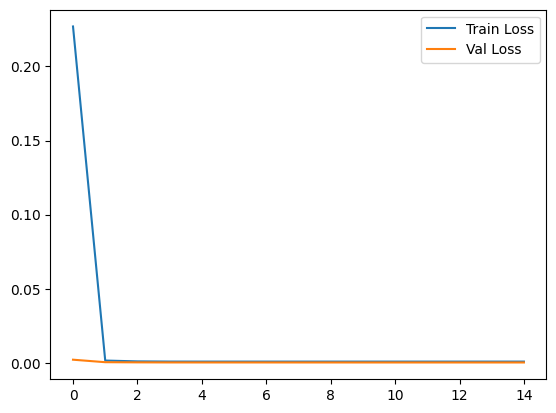

In [14]:
# plot training and validation losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

In [15]:
from utils import evaluate_accuracy
val_acc, val_buckets, wrongs = evaluate_accuracy(val_dataset, val_masks, weights, cfg, collect_wrongs=True)

Overall: 99975/100000 = 0.9998

digits carries      acc  count
     1       0    0.143  7
     1       1    0.000  3
     2       0    0.975  315
     2       1    0.987  457
     2       2    0.992  247
     3       0    1.000  16139
     3       1    1.000  35455
     3       2    1.000  33693
     3       3    1.000  13684
